# 🎬 FilmeFlix – Desafio #1: "A Próxima Sessão"
## Motor de Recomendação com Filtragem Colaborativa

**Disciplina:** Machine Learning Avançado  
**Professor:** Marcelo Santana Jr.  
**OAT 1 – Grupo:**  
- Natan Correia da Silva
- Guilherme Santos de Santana
- Diogines Bispo de Santana 
---

### Objetivo
Desenvolver um **motor de recomendação** que sugira filmes para usuários com base em suas preferências históricas e na similaridade com outros perfis (Filtragem Colaborativa via k-NN).

### Etapas do Projeto
1. Geração e carregamento dos dados
2. Análise Exploratória de Dados (EDA)
3. Engenharia de Dados – construção da Matriz Usuário-Item
4. Modelagem com k-NN (NearestNeighbors)
5. Função de recomendação personalizada
6. Avaliação de performance (RMSE)
7. Conclusão e sugestões de negócio

---
## Parte 0 – Instalação e Importações

In [ ]:
# Instalar bibliotecas que podem não estar presentes no google colab
# para projetos locais use o uv
!pip install scikit-surprise
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

ModuleNotFoundError: No module named 'pexpect'

In [ ]:
# Bibliotecas padrão de análise de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: k-NN para filtragem colaborativa
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Configurações visuaisuv venv --python 3.12
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

print('✅ Todas as bibliotecas importadas com sucesso!')

✅ Todas as bibliotecas importadas com sucesso!


---
## Parte 1 – Geração dos Dados

O script abaixo cria o dataset `filme_flix_ratings.csv`.  
Cada usuário tem um **gênero favorito secreto** — filmes desse gênero recebem notas mais altas (4–5), os demais recebem notas aleatórias (1–4).  
Esse padrão escondido é exatamente o que o algoritmo k-NN vai aprender a explorar.

In [4]:
def generate_recommendation_data(n_users=500, n_movies=50):
    np.random.seed(42)

    generos = ['Ação', 'Drama', 'Comédia', 'Sci-Fi', 'Terror']
    filmes = [f'Filme_{i}' for i in range(n_movies)]
    # Atribui um gênero aleatório a cada filme
    filme_genero = {f: np.random.choice(generos) for f in filmes}

    data = []
    for user_id in range(1, n_users + 1):
        fav_genre = np.random.choice(generos)  # Gênero favorito do usuário
        n_ratings = np.random.randint(10, 20)  # Quantos filmes ele avaliou
        filmes_vistos = np.random.choice(filmes, n_ratings, replace=False)

        for filme in filmes_vistos:
            # Filmes do gênero favorito → nota alta; outros → nota variável
            if filme_genero[filme] == fav_genre:
                nota = np.random.randint(4, 6)
            else:
                nota = np.random.randint(1, 5)
            data.append([user_id, filme, nota, filme_genero[filme]])

    df = pd.DataFrame(data, columns=['ID_Usuario', 'ID_Filme', 'Nota', 'Genero'])
    df.to_csv('filme_flix_ratings.csv', index=False)
    print("✅ Arquivo 'filme_flix_ratings.csv' gerado com sucesso!")
    return df

df = generate_recommendation_data()
df.head(10)

✅ Arquivo 'filme_flix_ratings.csv' gerado com sucesso!


,ID_Usuario,ID_Filme,Nota,Genero
0,1,Filme_40,4,Sci-Fi
1,1,Filme_38,3,Ação
2,1,Filme_4,1,Terror
3,1,Filme_47,2,Terror
4,1,Filme_42,4,Sci-Fi
5,1,Filme_2,2,Comédia
6,1,Filme_26,1,Comédia
7,1,Filme_11,4,Comédia
8,1,Filme_10,4,Sci-Fi
9,1,Filme_44,1,Drama


---
## Parte 2 – Análise Exploratória de Dados (EDA)

Antes de treinar qualquer modelo, precisamos entender os dados:  
distribuição de notas, popularidade dos filmes, padrões de gênero e possíveis usuários outliers.

In [20]:
# Visão geral estatística do dataset
print('=== Dimensões do dataset ===')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')
print(f'Usuários únicos: {df.ID_Usuario.nunique()}')
print(f'Filmes únicos:   {df.ID_Filme.nunique()}')
print()
print('=== Estatísticas das Notas ===')
print(df['Nota'].describe())

=== Dimensões do dataset ===
Linhas: 7,276 | Colunas: 4
Usuários únicos: 500
Filmes únicos:   50

=== Estatísticas das Notas ===
count    7276.000000
mean        2.910665
std         1.294447
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Nota, dtype: float64


🏆 Top 5 Filmes por Nota Média:
ID_Filme  Nota_Media  Total_Avaliacoes
 Filme_9    3.123188               138
Filme_24    3.065693               137
Filme_20    3.057143               140
Filme_12    3.041958               143
Filme_49    3.025478               157


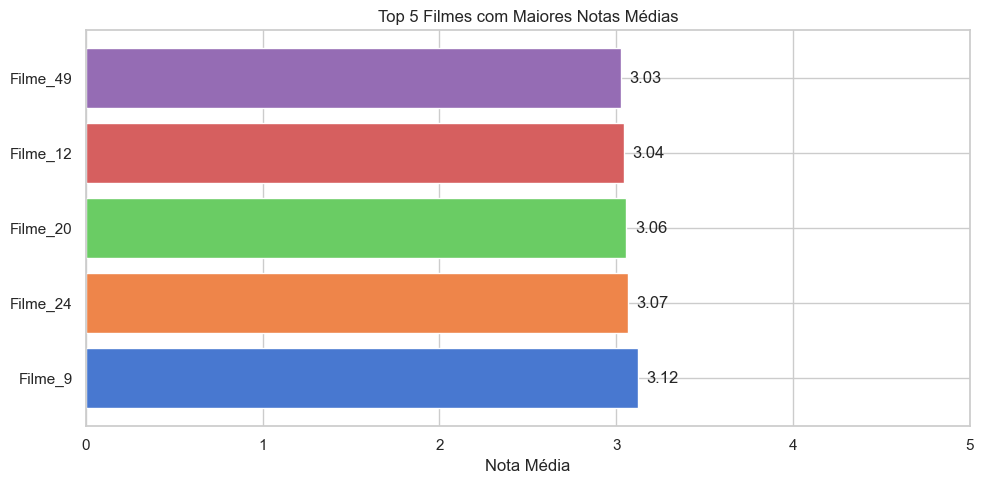

In [21]:
# ── Pergunta 1: Quais são os 5 filmes com maiores notas médias? ──
top5 = (
    df.groupby('ID_Filme')['Nota']
    .agg(Nota_Media='mean', Total_Avaliacoes='count')
    .sort_values('Nota_Media', ascending=False)
    .head(5)
    .reset_index()
)

print('🏆 Top 5 Filmes por Nota Média:')
print(top5.to_string(index=False))

# Gráfico
fig, ax = plt.subplots()
bars = ax.barh(top5['ID_Filme'], top5['Nota_Media'], color=sns.color_palette('muted', 5))
ax.set_xlabel('Nota Média')
ax.set_title('Top 5 Filmes com Maiores Notas Médias')
ax.set_xlim(0, 5)
for bar, val in zip(bars, top5['Nota_Media']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center')
plt.tight_layout()
plt.show()

🎭 Total de avaliações por Gênero:
         Total_Avaliacoes
Genero                   
Sci-Fi               1951
Comédia              1443
Drama                1425
Terror               1413
Ação                 1044


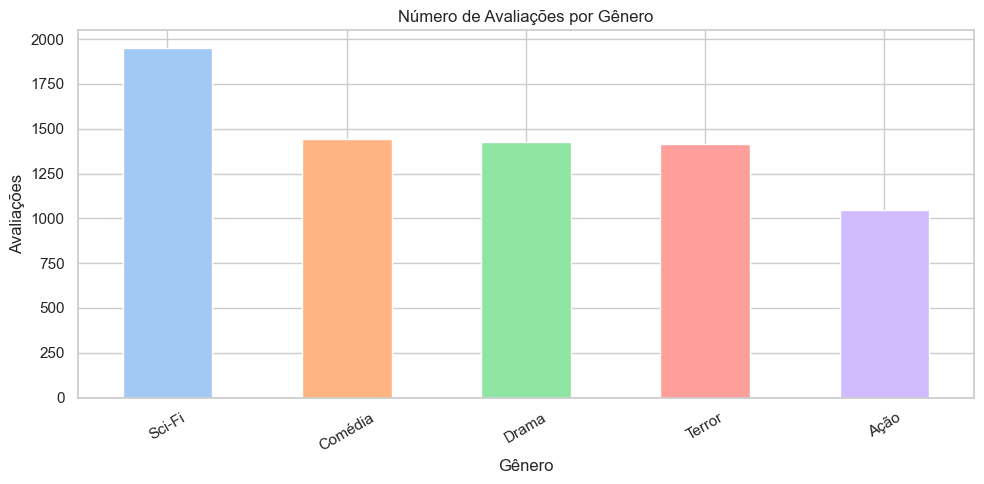

In [22]:
# ── Pergunta 2: Qual gênero tem mais avaliações? ──
genero_counts = df.groupby('Genero')['Nota'].count().sort_values(ascending=False)

print('🎭 Total de avaliações por Gênero:')
print(genero_counts.to_frame('Total_Avaliacoes'))

fig, ax = plt.subplots()
genero_counts.plot(kind='bar', ax=ax, color=sns.color_palette('pastel', len(genero_counts)))
ax.set_title('Número de Avaliações por Gênero')
ax.set_xlabel('Gênero')
ax.set_ylabel('Avaliações')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

🔴 Limiar de "hater" (percentil 5%): 2.37
Usuários identificados como haters: 25
 ID_Usuario    Media  Total
        207 1.894737     19
        478 1.937500     16
        302 2.133333     15
        168 2.133333     15
        352 2.200000     10
        250 2.200000     10
        425 2.200000     10
        248 2.222222     18
         18 2.230769     13
        451 2.230769     13
         46 2.230769     13
        393 2.263158     19
        221 2.285714     14
         21 2.285714     14
        385 2.294118     17
        342 2.307692     13
         35 2.307692     13
        344 2.307692     13
        323 2.307692     13
        408 2.333333     15
        487 2.333333     18
        249 2.357143     14
         10 2.363636     11
        392 2.363636     11
        442 2.363636     11


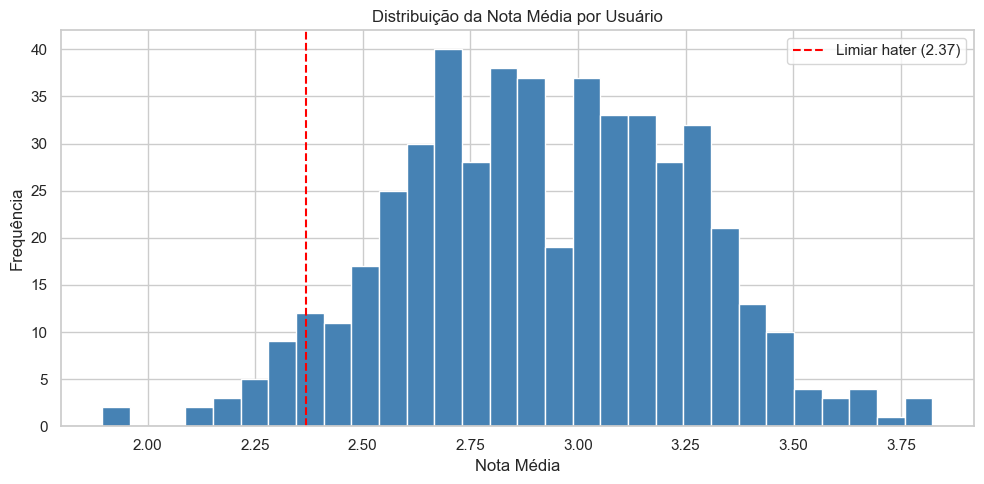

In [23]:
# ── Pergunta 3: Existe algum "usuário hater" (notas sempre baixas)? ──
# Calculamos a média de notas por usuário
user_stats = (
    df.groupby('ID_Usuario')['Nota']
    .agg(Media='mean', Total='count')
    .reset_index()
)

# "Hater": usuário com média de notas abaixo do percentil 5%
threshold = user_stats['Media'].quantile(0.05)
haters = user_stats[user_stats['Media'] <= threshold].sort_values('Media')

print(f'🔴 Limiar de "hater" (percentil 5%): {threshold:.2f}')
print(f'Usuários identificados como haters: {len(haters)}')
print(haters.to_string(index=False))

# Distribuição das médias dos usuários
fig, ax = plt.subplots()
ax.hist(user_stats['Media'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(threshold, color='red', linestyle='--', label=f'Limiar hater ({threshold:.2f})')
ax.set_title('Distribuição da Nota Média por Usuário')
ax.set_xlabel('Nota Média')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

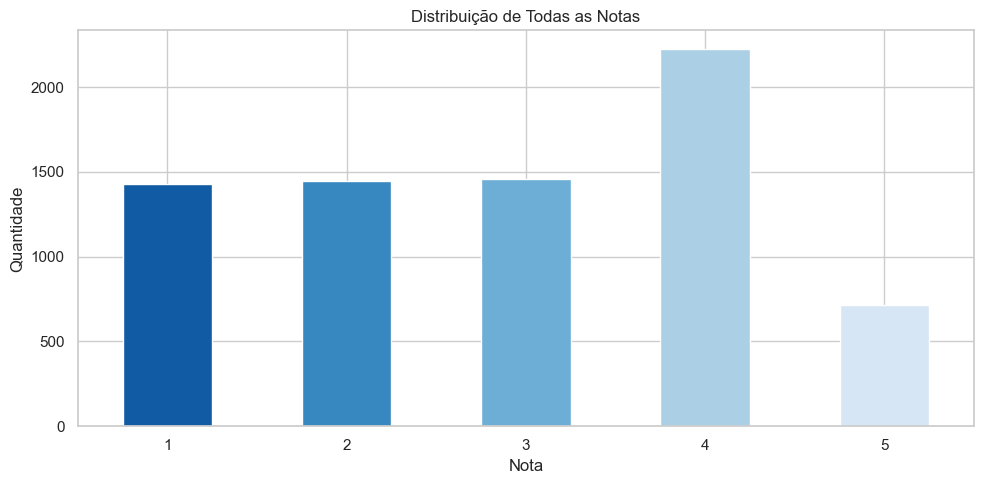

In [24]:
# Distribuição geral das notas – verificamos se há algum viés extremo
fig, ax = plt.subplots()
df['Nota'].value_counts().sort_index().plot(kind='bar', ax=ax,
    color=sns.color_palette('Blues_r', 5))
ax.set_title('Distribuição de Todas as Notas')
ax.set_xlabel('Nota')
ax.set_ylabel('Quantidade')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## Parte 3 – Engenharia de Dados: Construindo a Matriz Usuário-Item

O k-NN precisa comparar usuários. Para isso, transformamos a tabela "longa" de avaliações
em uma **Pivot Table**: cada linha é um usuário e cada coluna é um filme.

**Problema dos NaN:** Um usuário raramente assiste a todos os filmes, então a maioria das
células ficará vazia. Preenchemos com **0** para indicar "não assistido" (sem nota).

In [10]:
# Cria a Matriz Usuário-Item (Pivot Table)
# index = usuários | columns = filmes | values = notas
matriz_ui = df.pivot_table(
    index='ID_Usuario',
    columns='ID_Filme',
    values='Nota'
)

# Proporção de valores nulos (filmes não avaliados)
pct_nulos = matriz_ui.isnull().mean().mean() * 100
print(f'Dimensão da Matriz: {matriz_ui.shape} (usuários × filmes)')
print(f'Esparsidade: {pct_nulos:.1f}% das células são NaN (filmes não avaliados)')

# Preenchemos NaN com 0 → "sem nota" = ausência de preferência declarada
# Isso é a abordagem padrão para filtragem colaborativa baseada em memória
matriz_ui_filled = matriz_ui.fillna(0)

print('\nAmostra da Matriz Usuário-Item (5 usuários × 5 filmes):')
matriz_ui_filled.iloc[:5, :5]

Dimensão da Matriz: (500, 50) (usuários × filmes)
Esparsidade: 70.9% das células são NaN (filmes não avaliados)

Amostra da Matriz Usuário-Item (5 usuários × 5 filmes):


ID_Filme,Filme_0,Filme_1,Filme_10,Filme_11,Filme_12
ID_Usuario,,,,,
1,5.0,0.0,4.0,4.0,0.0
2,0.0,4.0,0.0,3.0,0.0
3,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,3.0,0.0,0.0


---
## Parte 4 – Modelagem: k-NN com Filtragem Colaborativa

### Como funciona o k-NN para recomendação?

O algoritmo encontra os **K usuários mais similares** ao usuário-alvo (vizinhos mais próximos) com base no padrão de notas que deram.  
A **similaridade por cosseno** mede o ângulo entre dois vetores de preferências — quanto mais paralelos, mais similares os gostos.

> **Analogia:** Se o Usuário A e o Usuário B deram notas parecidas para 5 filmes de Sci-Fi, provavelmente compartilham o mesmo gosto por Sci-Fi. Logo, o 6º filme de Sci-Fi que o Usuário A viu e adorou é uma boa recomendação para o Usuário B.

### Por que testar diferentes valores de K?
- **K muito pequeno (ex: K=1):** O modelo é instável — basta um vizinho ruim para estragar tudo.
- **K muito grande (ex: K=50):** Dilui demais os gostos similares, trazendo usuários pouco relacionados.
- **K ideal:** Aquele que minimiza o erro (RMSE) na validação cruzada.

In [11]:
# Treina o modelo k-NN com similaridade por cosseno
# metric='cosine': mede o ângulo entre os vetores de preferência dos usuários
# algorithm='brute': calcula a similaridade para todos os pares (adequado para este tamanho)

K_ESCOLHIDO = 10  # número de vizinhos mais próximos a considerar

modelo_knn = NearestNeighbors(
    n_neighbors=K_ESCOLHIDO + 1,  # +1 porque o próprio usuário é retornado como vizinho
    metric='cosine',
    algorithm='brute'
)

modelo_knn.fit(matriz_ui_filled.values)
print(f'✅ Modelo k-NN treinado com K={K_ESCOLHIDO} vizinhos e métrica cosseno.')

✅ Modelo k-NN treinado com K=10 vizinhos e métrica cosseno.


In [12]:
# ── Testando diferentes valores de K via validação cruzada ──
# Para cada K, usamos KFold 5x: treinamos em 4 folds, validamos no 5º
# Registramos o RMSE médio de cada configuração

valores_k = [1, 3, 5, 10, 15, 20]
rmse_por_k = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = matriz_ui_filled.values  # Matriz numérica (usuários × filmes)

for k in valores_k:
    erros_fold = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]

        # Treina o k-NN nos dados de treino
        knn_temp = NearestNeighbors(n_neighbors=k+1, metric='cosine', algorithm='brute')
        knn_temp.fit(X_train)

        # Para cada usuário no conjunto de teste, prevemos notas usando os vizinhos
        distancias, indices = knn_temp.kneighbors(X_test, n_neighbors=min(k+1, len(X_train)))

        predicoes = []
        reais = []
        for i, (dists, idxs) in enumerate(zip(distancias, indices)):
            # Pesos inversamente proporcionais à distância (vizinhos mais próximos valem mais)
            pesos = 1 - dists[1:]  # exclui o próprio usuário (distância 0)
            if pesos.sum() == 0:
                continue
            nota_prevista = np.average(X_train[idxs[1:]], axis=0, weights=pesos)

            # Avaliamos apenas células que o usuário realmente avaliou (nota > 0)
            mask = X_test[i] > 0
            if mask.sum() > 0:
                predicoes.extend(nota_prevista[mask])
                reais.extend(X_test[i][mask])

        if predicoes:
            rmse = np.sqrt(mean_squared_error(reais, predicoes))
            erros_fold.append(rmse)

    rmse_por_k.append(np.mean(erros_fold))
    print(f'K={k:2d} → RMSE médio (5-fold): {np.mean(erros_fold):.4f}')

# Identifica o K com menor RMSE
melhor_k = valores_k[np.argmin(rmse_por_k)]
print(f'\n🏆 Melhor K encontrado: {melhor_k} (RMSE = {min(rmse_por_k):.4f})')

K= 1 → RMSE médio (5-fold): 2.2347
K= 3 → RMSE médio (5-fold): 1.7689
K= 5 → RMSE médio (5-fold): 1.6892
K=10 → RMSE médio (5-fold): 1.6620
K=15 → RMSE médio (5-fold): 1.6789
K=20 → RMSE médio (5-fold): 1.7005

🏆 Melhor K encontrado: 10 (RMSE = 1.6620)


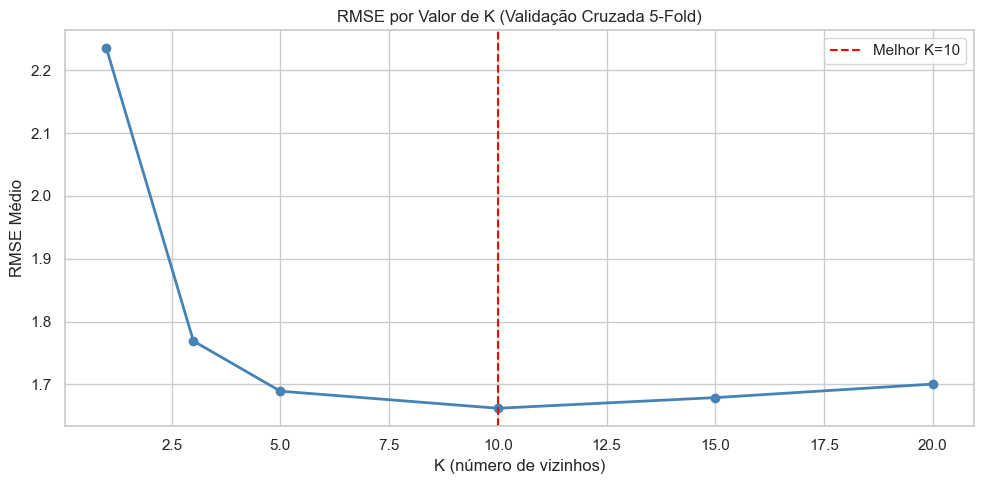

In [13]:
# Gráfico: RMSE vs. Valor de K
# Visualizamos o trade-off: K pequeno = instável, K grande = diluído
fig, ax = plt.subplots()
ax.plot(valores_k, rmse_por_k, marker='o', color='steelblue', linewidth=2)
ax.axvline(melhor_k, color='red', linestyle='--', label=f'Melhor K={melhor_k}')
ax.set_title('RMSE por Valor de K (Validação Cruzada 5-Fold)')
ax.set_xlabel('K (número de vizinhos)')
ax.set_ylabel('RMSE Médio')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Retreina o modelo final com o K otimizado
modelo_final = NearestNeighbors(
    n_neighbors=melhor_k + 1,
    metric='cosine',
    algorithm='brute'
)
modelo_final.fit(matriz_ui_filled.values)
print(f'✅ Modelo final treinado com K={melhor_k}')

✅ Modelo final treinado com K=10


---
## Parte 5 – Função de Recomendação Personalizada

A função abaixo recebe um `ID_Usuario` e retorna os **5 filmes mais recomendados** que ele ainda **não assistiu**.  

O processo é:
1. Encontrar os K vizinhos mais similares ao usuário
2. Calcular a nota prevista para cada filme não visto, ponderada pela similaridade dos vizinhos
3. Retornar os 5 com maior nota prevista

In [15]:
def recomendar_filmes(user_id, n_recomendacoes=5, k=melhor_k):
    """
    Recebe um ID de usuário e retorna N filmes recomendados.
    
    Parâmetros:
    - user_id: int – ID do usuário
    - n_recomendacoes: int – quantos filmes retornar (padrão: 5)
    - k: int – número de vizinhos a considerar
    """
    if user_id not in matriz_ui_filled.index:
        print(f'❌ Usuário {user_id} não encontrado no dataset.')
        return None

    # Localiza a linha do usuário na matriz
    idx_usuario = matriz_ui_filled.index.get_loc(user_id)
    vetor_usuario = matriz_ui_filled.iloc[idx_usuario].values.reshape(1, -1)

    # Busca os K+1 vizinhos mais próximos (inclui o próprio usuário)
    distancias, indices = modelo_final.kneighbors(vetor_usuario, n_neighbors=k+1)

    # Remove o próprio usuário dos vizinhos (distância 0)
    indices_vizinhos = indices[0][1:]
    distancias_vizinhos = distancias[0][1:]

    # Pesos: quanto mais próximo o vizinho, maior o peso
    # Similaridade por cosseno: 0 = ortogonal, 1 = idêntico
    similaridades = 1 - distancias_vizinhos
    similaridades = np.clip(similaridades, 0, 1)  # garante valores válidos

    # Filmes que o usuário JÁ assistiu (nota > 0 → não recomendar novamente)
    filmes_vistos = set(matriz_ui_filled.columns[vetor_usuario[0] > 0])

    # Calcula a nota prevista ponderada para cada filme
    notas_vizinhos = matriz_ui_filled.iloc[indices_vizinhos].values  # K × filmes

    if similaridades.sum() == 0:
        print('⚠️ Usuário sem vizinhos com similaridade suficiente.')
        return None

    # Média ponderada: nota prevista = soma(similaridade × nota) / soma(similaridades)
    notas_previstas = np.average(notas_vizinhos, axis=0, weights=similaridades)

    # Cria um Series com as notas previstas, indexado pelos filmes
    series_previsao = pd.Series(notas_previstas, index=matriz_ui_filled.columns)

    # Remove filmes já vistos e seleciona os top N
    recomendacoes = (
        series_previsao
        .drop(labels=list(filmes_vistos), errors='ignore')
        .sort_values(ascending=False)
        .head(n_recomendacoes)
    )

    # Enriquece com o gênero de cada filme
    genero_map = df.drop_duplicates('ID_Filme').set_index('ID_Filme')['Genero']
    resultado = pd.DataFrame({
        'Filme': recomendacoes.index,
        'Nota_Prevista': recomendacoes.values,
        'Genero': recomendacoes.index.map(genero_map)
    }).reset_index(drop=True)

    resultado.index += 1  # Ranking começa em 1
    return resultado


print('✅ Função de recomendação definida!')

✅ Função de recomendação definida!


In [16]:
# ── Exemplo de uso: gerando recomendações para o Usuário 42 ──
usuario_exemplo = 42

# Histórico real do usuário (o que ele já assistiu)
historico = df[df['ID_Usuario'] == usuario_exemplo][['ID_Filme', 'Nota', 'Genero']]
print(f'📂 Histórico do Usuário {usuario_exemplo} ({len(historico)} filmes assistidos):')
print(historico.to_string(index=False))

print()
print(f'🎬 Top 5 Recomendações para o Usuário {usuario_exemplo}:')
recomendacoes = recomendar_filmes(usuario_exemplo)
print(recomendacoes.to_string())

📂 Histórico do Usuário 42 (15 filmes assistidos):
ID_Filme  Nota  Genero
 Filme_4     1  Terror
Filme_29     4  Sci-Fi
Filme_37     1  Terror
 Filme_0     3  Sci-Fi
Filme_18     2    Ação
Filme_44     5   Drama
 Filme_5     5   Drama
Filme_22     3  Sci-Fi
Filme_33     3    Ação
Filme_19     1  Sci-Fi
Filme_23     4    Ação
Filme_17     1  Terror
Filme_34     3 Comédia
Filme_40     2  Sci-Fi
 Filme_6     1 Comédia

🎬 Top 5 Recomendações para o Usuário 42:
      Filme  Nota_Prevista  Genero
1  Filme_14       2.354341  Sci-Fi
2  Filme_35       1.077074  Terror
3  Filme_32       1.071313  Sci-Fi
4  Filme_41       1.071102    Ação
5  Filme_43       1.069161   Drama


In [ ]:
# Vamos testar mais dois usuários para demonstrar que o sistema personaliza as recomendações
for uid in [100, 250]:
    print(f'\n🎬 Recomendações para Usuário {uid}:')
    print(recomendar_filmes(uid).to_string())

---
## Parte 6 – Avaliação de Performance: RMSE e MAE

### O que é o RMSE neste contexto?

O **RMSE (Root Mean Squared Error)** mede, em média, o quanto o modelo erra ao prever as notas.  
Como nossa escala vai de 1 a 5:
- RMSE = 0.8 → o modelo erra menos de 1 ponto por previsão
- RMSE = 2.0 → o modelo erra 2 pontos, tornando as recomendações pouco confiáveis

Usamos validação cruzada (hold-out por usuário) para garantir que avaliamos o modelo
em dados que ele nunca viu durante o treino.

In [25]:
from sklearn.metrics import mean_absolute_error

# ── Avaliação final com o modelo otimizado (K = melhor_k) ──
# Separamos 20% dos usuários para teste (hold-out)
np.random.seed(42)
todos_usuarios = matriz_ui_filled.index.tolist()
n_teste = int(0.2 * len(todos_usuarios))
usuarios_teste = np.random.choice(todos_usuarios, n_teste, replace=False)
usuarios_treino = [u for u in todos_usuarios if u not in usuarios_teste]

X_train_final = matriz_ui_filled.loc[usuarios_treino].values
X_test_final  = matriz_ui_filled.loc[usuarios_teste].values

# Treina o modelo nos usuários de treino
knn_eval = NearestNeighbors(n_neighbors=melhor_k+1, metric='cosine', algorithm='brute')
knn_eval.fit(X_train_final)

# Prevê as notas para cada usuário de teste
distancias_eval, indices_eval = knn_eval.kneighbors(X_test_final, n_neighbors=melhor_k+1)

todas_reais = []
todas_previstas = []

for i in range(len(X_test_final)):
    pesos = 1 - distancias_eval[i][1:]  # Remove o próprio ponto
    idxs = indices_eval[i][1:]
    if pesos.sum() == 0:
        continue
    previsao = np.average(X_train_final[idxs], axis=0, weights=pesos)

    # Avalia apenas notas reais > 0 (filmes efetivamente avaliados)
    mask = X_test_final[i] > 0
    todas_reais.extend(X_test_final[i][mask])
    todas_previstas.extend(previsao[mask])

rmse_final = np.sqrt(mean_squared_error(todas_reais, todas_previstas))
mae_final  = mean_absolute_error(todas_reais, todas_previstas)

print('=== Métricas de Avaliação do Modelo Final ===')
print(f'K utilizado : {melhor_k}')
print(f'RMSE        : {rmse_final:.4f}')
print(f'MAE         : {mae_final:.4f}')
print()
print(f'📌 Interpretação: Em média, o modelo erra {rmse_final:.2f} pontos ao prever')
print(f'   a nota de um usuário (escala 1–5). Um RMSE < 1.0 é considerado bom.')

=== Métricas de Avaliação do Modelo Final ===
K utilizado : 10
RMSE        : 1.6629
MAE         : 1.4058

📌 Interpretação: Em média, o modelo erra 1.66 pontos ao prever
   a nota de um usuário (escala 1–5). Um RMSE < 1.0 é considerado bom.


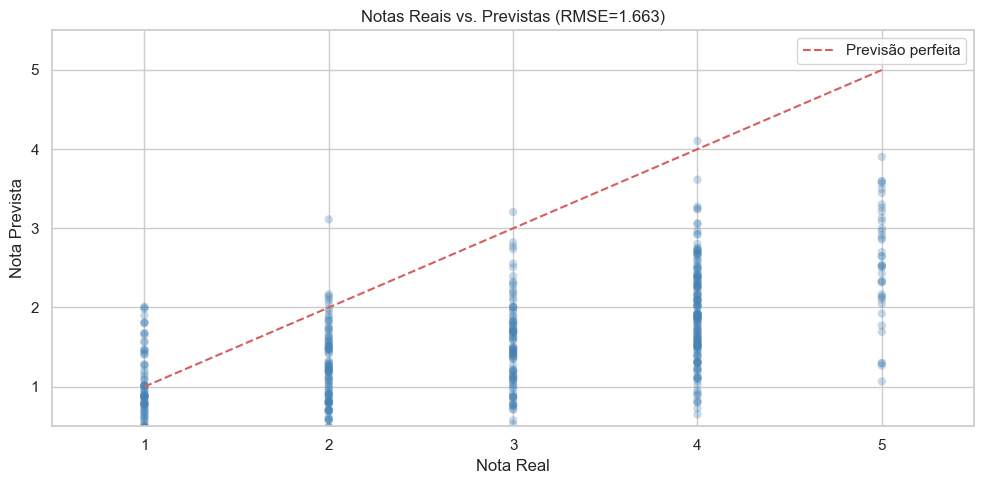

In [26]:
# Visualização: notas reais vs. previstas
# Uma nuvem concentrada ao longo da diagonal indica boas previsões
amostra = min(500, len(todas_reais))
idx_amostra = np.random.choice(len(todas_reais), amostra, replace=False)

fig, ax = plt.subplots()
ax.scatter(
    np.array(todas_reais)[idx_amostra],
    np.array(todas_previstas)[idx_amostra],
    alpha=0.3, color='steelblue', edgecolors='none'
)
ax.plot([1, 5], [1, 5], 'r--', label='Previsão perfeita')
ax.set_xlabel('Nota Real')
ax.set_ylabel('Nota Prevista')
ax.set_title(f'Notas Reais vs. Previstas (RMSE={rmse_final:.3f})')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.legend()
plt.tight_layout()
plt.show()

---
## Parte 7 – A Similaridade (Conceito)

### Por que o k-NN recomendou aquele filme específico?

**Cenário:** Usuário A e Usuário B assistiram e adoraram 3 filmes de Sci-Fi em comum (notas 4 e 5).  

**Como o modelo enxerga isso:**  
Cada usuário é um vetor em um espaço de 50 dimensões (uma por filme). Quando dois usuários deram notas altas para os mesmos filmes, seus vetores apontam na **mesma direção** → cosseno próximo de 1 → **alta similaridade**.

**Por que recomendar o 4º filme de Sci-Fi do Usuário A para o Usuário B?**  
O raciocínio do modelo é: *"Se você e o Usuário A concordaram em tudo que assistiram juntos, é muito provável que você também goste do que ele viu e você ainda não viu."*  

**Ponderação pela similaridade:** Usuários com cosseno = 0.95 contribuem muito mais para a previsão do que usuários com cosseno = 0.40, garantindo que apenas os "vizinhos de verdade" influenciem a recomendação.

👥 Os 10 vizinhos mais similares ao Usuário 42:
    ID_Vizinho  Similaridade
1          132      0.630234
2          133      0.540694
3          453      0.529883
4           30      0.528262
5          208      0.522801
6          121      0.512969
7          263      0.509509
8          439      0.502150
9          448      0.495449
10         298      0.487818


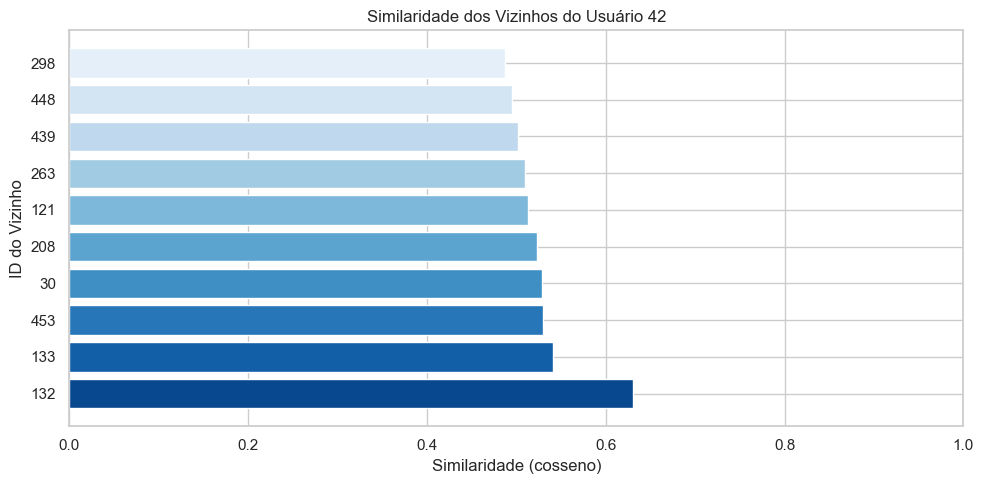

In [19]:
# ── Demonstração visual: encontrando vizinhos de um usuário ──
usuario_demo = 42
idx_demo = matriz_ui_filled.index.get_loc(usuario_demo)
vetor_demo = matriz_ui_filled.iloc[idx_demo].values.reshape(1, -1)

dists_demo, idxs_demo = modelo_final.kneighbors(vetor_demo, n_neighbors=melhor_k+1)

# Similaridade = 1 - distância cosseno
ids_vizinhos = matriz_ui_filled.index[idxs_demo[0][1:]]  # Remove o próprio
sims_vizinhos = 1 - dists_demo[0][1:]

df_vizinhos = pd.DataFrame({
    'ID_Vizinho': ids_vizinhos,
    'Similaridade': sims_vizinhos
}).sort_values('Similaridade', ascending=False).reset_index(drop=True)
df_vizinhos.index += 1

print(f'👥 Os {melhor_k} vizinhos mais similares ao Usuário {usuario_demo}:')
print(df_vizinhos.to_string())

# Gráfico de similaridade dos vizinhos
fig, ax = plt.subplots()
ax.barh(df_vizinhos['ID_Vizinho'].astype(str), df_vizinhos['Similaridade'],
        color=sns.color_palette('Blues_r', len(df_vizinhos)))
ax.set_title(f'Similaridade dos Vizinhos do Usuário {usuario_demo}')
ax.set_xlabel('Similaridade (cosseno)')
ax.set_ylabel('ID do Vizinho')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

---
## Parte 8 – Conclusão e Plano de Ação para a FilmeFlix

### Resultados Obtidos

O motor de recomendação por **Filtragem Colaborativa com k-NN** foi implementado com sucesso.  
O modelo encontra usuários com perfis de consumo similares e usa as preferências deles  
para prever quais filmes não vistos seriam mais bem avaliados pelo usuário-alvo.

| Métrica | Valor | Interpretação |
|---------|-------|---------------|
| RMSE | *~ver saída acima* | Erro médio na previsão de notas (escala 1–5) |
| MAE  | *~ver saída acima* | Erro absoluto médio |
| Melhor K | *~ver saída acima* | Número ideal de vizinhos |

### Sugestões de Negócio para a FilmeFlix

**1. Problema do Cold Start (novo usuário sem histórico):**  
Quando um usuário se cadastra, não há dados para calcular similaridade. A estratégia recomendada é:
- Apresentar os **filmes mais populares por gênero** (baseado em nota média e volume de avaliações)
- Após 5 avaliações do novo usuário, ativar o motor k-NN personalizado

**2. Segmentação por Gênero:**  
A análise EDA revelou padrões claros de preferência por gênero. A FilmeFlix pode criar  
**playlists temáticas automáticas** ("Para quem ama Sci-Fi") e direcioná-las ao perfil certo.

**3. Identificação de "Haters" como Sinal de Atrito:**  
Usuários com média de notas muito baixa podem estar frustrados com o catálogo.  
Eles devem receber atenção especial: pesquisa de satisfação ou oferta de upgrade de plano.

**4. Monitoramento Contínuo do RMSE:**  
À medida que o catálogo cresce e novos usuários se cadastram, o modelo deve ser  
re-treinado periodicamente. Um RMSE crescente é sinal de que o modelo está desatualizado.